In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import Axes3D")

import os
import platform

# Workaround for Windows
if platform.system() == "Windows":
    os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset


import random
import time
import numpy as np
import pandas as pd
import h5py
from datetime import datetime
import csv
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from utils import process_traces, create_labels

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
%matplotlib inline


if torch.cuda.is_available():
    device = torch.device("cuda")  # GPU available
else:
    device = torch.device("cpu")  # Only CPU available

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device

device(type='cpu')

### 1. Data Loading

This notebook provides two ways to load the seismic data:
1. **Quick Start (Default):** Uses a lightweight, pre-processed sample dataset (`stead_sample100.pt`) included in this repository. This allows you to run the notebook end-to-end in seconds without downloading massive files.
2. **Full Reproduction:** To train the model on the full 500/100/1000 splits and reproduce the metrics shown in the paper, change the toggle below to `USE_SAMPLE_DATA = False`. You will need to download the full STEAD dataset (`merge.hdf5`) and place it in the `./data/` directory. *(See README.md for download links).*

In [2]:
# --- Dataset Configuration Toggle ---
# Set to True for a quick test run. Set to False for full paper reproduction.
USE_SAMPLE_DATA = True 
# ------------------------------------

if USE_SAMPLE_DATA:
    print("Loading lightweight sample dataset...")
    sample_path = './sample_data/stead_sample100.pt'
    
    # Load the dictionary from the .pt file
    data = torch.load(sample_path, weights_only=True)
    
    # Extract the variables
    x_train = data['x_train']
    y_train = data['y_train']
    x_val   = data['x_val']
    y_val   = data['y_val']
    x_test  = data['x_test']
    y_test  = data['y_test']
    
    print(f"Sample data loaded! Train: {x_train.shape[0]}, Val: {x_val.shape[0]}, Test: {x_test.shape[0]}")

else:
    print("Loading full STEAD dataset from CSV and HDF5...")
    # Please download to ./data from:
    # https://drive.google.com/file/d/1oiuS7ByCyE2-7rARs6jXWN34Amf-Vrbg/view
    
    # Define paths for the full dataset
    DATA_DIR = "./data/"    
    HDF5_PATH = os.path.join(DATA_DIR, "merged.hdf5")
    CSV_PATH = os.path.join(DATA_DIR, "stead_train500.csv")
            
    dtfl = h5py.File(HDF5_PATH, 'r')
        
    # 1. Load the CSV      
    df_loaded = pd.read_csv(CSV_PATH)

    # 2. Reconstruct Earthquake Lists
    train_traces_eq = df_loaded[(df_loaded['split'] == 'train') & (df_loaded['label'] == 'earthquake')]['trace_name'].tolist()
    val_traces_eq = df_loaded[(df_loaded['split'] == 'validation') & (df_loaded['label'] == 'earthquake')]['trace_name'].tolist()
    test_traces_eq = df_loaded[(df_loaded['split'] == 'test') & (df_loaded['label'] == 'earthquake')]['trace_name'].tolist()

    # 3. Reconstruct Noise Lists
    train_traces_noise = df_loaded[(df_loaded['split'] == 'train') & (df_loaded['label'] == 'noise')]['trace_name'].tolist()
    val_traces_noise = df_loaded[(df_loaded['split'] == 'validation') & (df_loaded['label'] == 'noise')]['trace_name'].tolist()
    test_traces_noise = df_loaded[(df_loaded['split'] == 'test') & (df_loaded['label'] == 'noise')]['trace_name'].tolist()

    # 4. Quick verification
    print("--- Recovered Lists ---")
    print(f"EQ    -> Train: {len(train_traces_eq)}, Val: {len(val_traces_eq)}, Test: {len(test_traces_eq)}")
    print(f"Noise -> Train: {len(train_traces_noise)}, Val: {len(val_traces_noise)}, Test: {len(test_traces_noise)}")

    # Preallocate
    total_traces = len(train_traces_eq) + len(train_traces_noise)
    total_traces_val = len(val_traces_eq) + len(val_traces_noise)
    total_traces_test = len(test_traces_eq) + len(test_traces_noise)
    
    x_train = np.empty((total_traces, 6000, 3))
    x_val = np.empty((total_traces_val, 6000, 3))
    x_test = np.empty((total_traces_test, 6000, 3))

    # Process both EQ and NOISE sets
    process_traces(train_traces_eq, dtfl, 0, x_train)
    process_traces(train_traces_noise, dtfl, len(train_traces_eq), x_train)
                   
    process_traces(val_traces_eq, dtfl, 0, x_val)
    process_traces(val_traces_noise, dtfl, len(val_traces_eq), x_val)
    
    process_traces(test_traces_eq, dtfl, 0, x_test)
    process_traces(test_traces_noise, dtfl, len(test_traces_eq), x_test)
    
    # Construct labels for all sets
    y_train = create_labels(train_traces_eq, train_traces_noise)
    y_val   = create_labels(val_traces_eq, val_traces_noise)
    y_test  = create_labels(test_traces_eq, test_traces_noise)
    
    # Torchify
    x_train = torch.from_numpy(x_train)
    y_train = torch.from_numpy(y_train)

    x_val = torch.from_numpy(x_val)
    y_val = torch.from_numpy(y_val)

    x_test = torch.from_numpy(x_test)
    y_test = torch.from_numpy(y_test)
        
    print("-" * 30)
    print("Full dataset loaded successfully.")

# Print tensor shapes to confirm successful loading regardless of the method used
print("-" * 30)
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("-" * 30)

Loading lightweight sample dataset...
Sample data loaded! Train: 100, Val: 100, Test: 100
------------------------------
x_train shape: torch.Size([100, 6000, 3])
y_train shape: torch.Size([100])
------------------------------


### 2. PRE-PROCESSING

In [3]:
print(f'Input size of training data: {np.shape(x_train)}')
print(f'output size of training data: {np.shape(y_train)}')
print('--'*50)
print(f'Input size of validation data: {np.shape(x_val)}')
print(f'output size of validation data: {np.shape(y_val)}')
print('--'*50)
print(f'input size of test data: {np.shape(x_test)}')
print(f'output size of test data: {np.shape(y_test)}')

Input size of training data: torch.Size([100, 6000, 3])
output size of training data: torch.Size([100])
----------------------------------------------------------------------------------------------------
Input size of validation data: torch.Size([100, 6000, 3])
output size of validation data: torch.Size([100])
----------------------------------------------------------------------------------------------------
input size of test data: torch.Size([100, 6000, 3])
output size of test data: torch.Size([100])


In [4]:
x_train = x_train.type('torch.FloatTensor')
y_train =  y_train.type('torch.FloatTensor')

x_val = x_val.type('torch.FloatTensor')
y_val = y_val.type('torch.FloatTensor')

x_test = x_test.type('torch.FloatTensor')
y_test = y_test.type('torch.FloatTensor')

In [5]:
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=1, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=1, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=1, shuffle=False)

### 3. FNO ARCHITECTURE

---

### 1D Fourier Layer (Spectral Convolution)

This layer performs a linear convolution in the physical domain by executing a pointwise multiplication in the Fourier (frequency) domain, based on the convolution theorem. 

Given an input sequence $v(x)$, the operation evaluates:
$$v_{out}(x) = \mathcal{F}^{-1} \left( R \cdot \mathcal{F}(v)(k) \right)(x)$$

The forward pass in this class executes this in three distinct steps:
1. **Fourier Transform ($\mathcal{F}$):** The input is transformed into the frequency domain using a Real Fast Fourier Transform (`torch.fft.rfft`), yielding its complex Fourier coefficients.
2. **Linear Transformation ($R$):** The model applies a low-pass filter by retaining only the lower frequency modes (up to `modes1`). These retained modes are multiplied by a learnable complex weight tensor $R$ (`self.compl_mul1d`). The higher frequency modes are truncated, which makes the model computationally lightweight and resolution-invariant.
3. **Inverse Fourier Transform ($\mathcal{F}^{-1}$):** The modulated frequencies are transformed back into the physical sequence space using the Inverse Real Fast Fourier Transform (`torch.fft.irfft`).

---

In [6]:
class SpectralConv1d(nn.Module):
    
    def __init__( self, in_channels, out_channels, modes1 ):
        
        super(SpectralConv1d, self).__init__()
        
        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 # Number of Fourier modes to multiply, at most floor(N/2) + 1

        self.scale = (1 / (in_channels * out_channels))
    
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        
        # (batch, in_channel, x), (in_channel, out_channel, x) -> (batch, out_channel, x)
        
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        
        batchsize = x.shape[0]
        
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x, norm = 'forward')

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        
        out_ft[:, :, :self.modes1] = \
            self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights1)

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1) , norm = 'forward')
        
        return x

---

### 1D Fourier Neural Operator (FNO) Architecture

This class defines the complete 1D FNO network tailored for binary classification of seismic time-series data. It maps an input sequence (a 3-component seismogram) to a single probability score indicating the presence of a seismic event.

The network architecture consists of four main stages:

1. **Lifting Layer (`fc0`):** Projects the raw 3-channel input (E, N, Z components) into a higher-dimensional latent space of size `width`.
   
2. **Integral Operator Blocks (FNO Layers):** The core of the network consists of **3 sequential FNO layers**. Each layer updates the hidden representation $v_t$ using both global and local transformations:
   $$v_{t+1}(x) = \sigma \left( \mathcal{K}(v_t)(x) + W(v_t)(x) \right)$$
   * **Global Integration ($\mathcal{K}$):** The `SpectralConv1d` layer performs convolution in the Fourier domain, capturing long-range temporal dependencies.
   * **Local Linear Transform ($W$):** A standard 1D convolution with a kernel size of 1 (`nn.Conv1d`) captures local, point-wise features.
   * **Activation ($\sigma$):** A Gaussian Error Linear Unit (GELU) is applied after the addition.

3. **Global Temporal Pooling:** After projecting the features with a linear layer (`fc1`), the network applies a Global Max Pooling operation over the time dimension. This aggregates the temporal features into a single, fixed-size vector per trace, transitioning the model from sequence-to-sequence mapping to sequence-to-vector classification.

4. **Classification Head:** A Multi-Layer Perceptron (MLP) consisting of fully connected layers (`fc10`, `fc20`, `fc30`) with Dropout for regularization. A final Sigmoid activation squashes the output into a probability range $[0, 1]$.

---

In [7]:
class SimpleBlock1d(nn.Module):
    
    def __init__(self, modes1, width):
        
        super(SimpleBlock1d, self).__init__()
                        
        self.modes1 = modes1
        self.width = width
    
        self.fc0 = nn.Linear(3, self.width) # input channel is 3     

        """        
        3 channels: E, N, Z
        """
        
        # 3 FNOs sequential
        self.conv0 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv2 = SpectralConv1d(self.width, self.width, self.modes1)
        
        # 3 weight layers
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
               
        self.fc1 = nn.Linear(self.width, self.width)
               
        self.fc10 = nn.Linear(self.width, 64*2)
        self.bn10 = nn.BatchNorm1d(64*2)
        self.dropout10 = nn.Dropout(0.3)
        
        self.fc20 = nn.Linear(64*2, 64*2)
        self.bn20 = nn.BatchNorm1d(64*2)
        self.dropout20 = nn.Dropout(0.3)
      
        self.fc30 = nn.Linear(64*2, 1)

    def forward(self, x):
        
        batchsize = x.shape[0]
        size_x = x.shape[1]

        x = self.fc0(x)
        x = x.permute(0, 2, 1)

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2         
        x = F.gelu(x)
        
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2         
        x = F.gelu(x)
        
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2         
        x = F.gelu(x)
            
        x = x.permute(0, 2, 1)
        x = self.fc1(x)    
        x = F.gelu(x)
        
        x = x.view(x.size(0), -1, x.size(-1)).max(dim=1).values
        
        # Pass through three fully connected layers with dropout without batch
        x = self.dropout10(F.gelu(self.fc10(x)))
        x = self.dropout20(F.gelu(self.fc20(x)))
               
        x = self.fc30(x)        
        x = torch.sigmoid(x)
        
        return x

In [8]:
# Model initialization

modes = 16
width = 32

model = SimpleBlock1d(modes, width).to(device)

### 4. TRAINING

In [9]:
# Define loss function and optimizer

learning_rate = 1e-3
optimizer = optim.AdamW( model.parameters(), lr=learning_rate, weight_decay=1e-4 )

scheduler = ReduceLROnPlateau( optimizer, mode='min', factor=0.5, patience=10 )

loss_function = nn.BCELoss()
  
patience = 20  # Number of epochs to wait before stopping

In [10]:
### Training Loop ###

today = datetime.today().date()

num_epochs = 1000                                                            
train_losses = []
val_losses = []        
trigger_times = 0  # Counter for early stopping

# --- Initialize these BEFORE the training loop starts ---
best_model_path = None  # Tracks the filename of the currently saved best model
best_val_loss = float('inf')

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader :

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).view(-1)

        loss = loss_function(outputs, targets)
        loss.backward()

        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(x_train) # need to account for batch size
    train_losses.append( avg_train_loss )

    model.eval()    
    val_loss = 0.0

    with torch.no_grad():

        for inputs, targets in val_loader :

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs).view(-1)

            loss = loss_function(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(x_val)
    val_losses.append( avg_val_loss )

    scheduler.step( avg_val_loss ) # Update learning rate

    # Calculate delta (handle the first epoch where best_val_loss is infinity)
    current_delta = 0.01 * best_val_loss if best_val_loss != float('inf') else 0            

    # Save the model with the best validation loss + Early stopping logic
    if avg_val_loss < best_val_loss - current_delta:

        # 1. Clean up: Remove the PREVIOUS best model if it exists
        if best_model_path is not None and os.path.exists(best_model_path):
            try:
                os.remove(best_model_path)
            except OSError:
                pass  # Safety: ignore errors if file was already deleted/moved

        # 2. Update State
        best_val_loss = avg_val_loss
        trigger_times = 0

        # 3. Save New Model
        # Construct the new filename using the NEW best loss
        best_model_path = f"./models/model_stead_m{modes}_w{width}_val{best_val_loss:.3f}_{today}.pth"
        torch.save(model.state_dict(), best_model_path)

    else:
        trigger_times += 1

        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if (epoch+1) % 5 == 0 :

        # Print the average validation loss for this epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.2e}, Val Loss: {avg_val_loss:.2e}")

        # Access the current learning rate
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}: Current Learning Rate = {current_lr:.1e}")
       

Epoch [5/1000], Train Loss: 8.84e-02, Val Loss: 1.56e-01
Epoch 5: Current Learning Rate = 1.0e-03
Epoch [10/1000], Train Loss: 1.18e-03, Val Loss: 1.86e-01
Epoch 10: Current Learning Rate = 1.0e-03
Epoch [15/1000], Train Loss: 2.17e-04, Val Loss: 2.20e-01
Epoch 15: Current Learning Rate = 5.0e-04
Epoch [20/1000], Train Loss: 1.21e-04, Val Loss: 2.45e-01
Epoch 20: Current Learning Rate = 5.0e-04
Early stopping at epoch 22


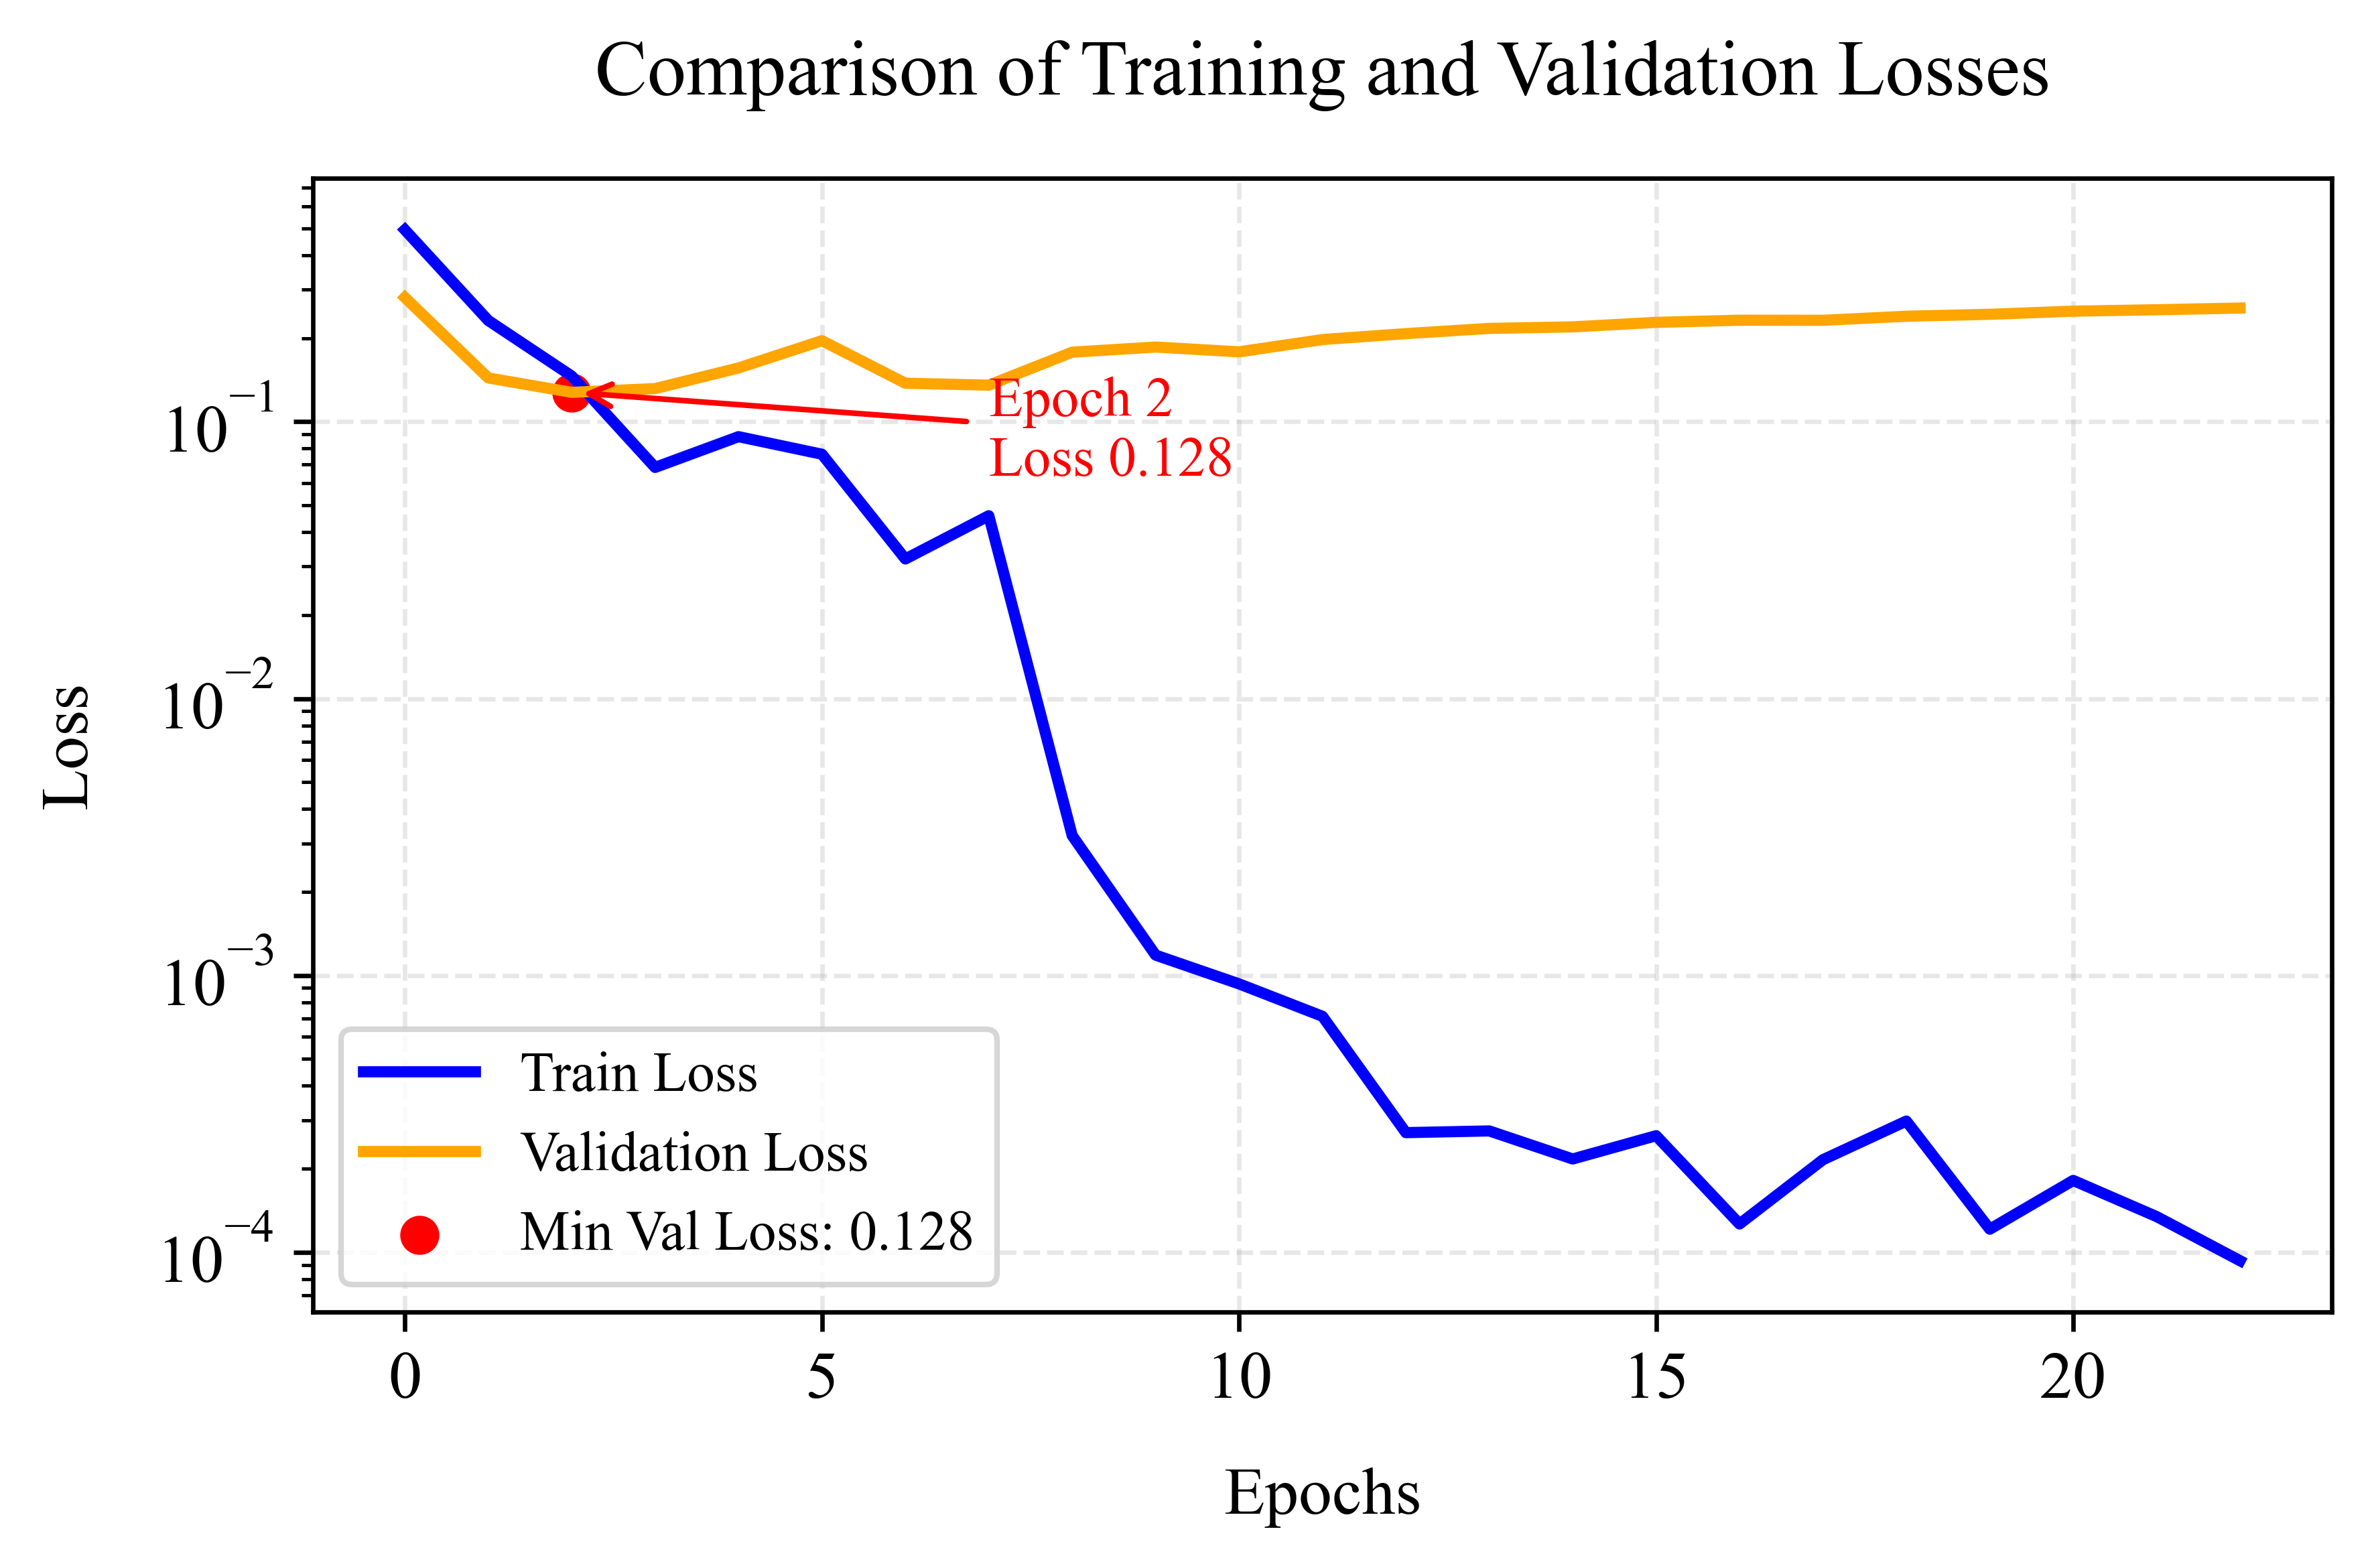

In [11]:
### Loss Figure ###
fig = plt.figure(figsize=(6, 4), dpi=600)  # Slightly larger for presentations
ax = plt.axes()

# Plot train and validation losses
ax.semilogy(train_losses, linewidth=2, color='blue', label='Train Loss')
ax.semilogy(val_losses, linewidth=2, color='orange', label='Validation Loss')

# Add grid, labels, and title
ax.set_xlabel('Epochs', fontsize=12, labelpad=10)
ax.set_ylabel('Loss', fontsize=12, labelpad=10)
ax.set_title('Comparison of Training and Validation Losses', fontsize=14, pad=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3, linestyle='--')

# Annotate minimum validation loss
min_val_loss = np.array(val_losses).min()
min_epoch = val_losses.index(min_val_loss)

ax.scatter(min_epoch, min_val_loss, color='red', label=f'Min Val Loss: {min_val_loss:.3f}')

ax.annotate(f'Epoch {min_epoch}\nLoss {min_val_loss:.3f}', 
            xy=(min_epoch, min_val_loss), 
            xytext=(min_epoch + 5, min_val_loss / 2),
            arrowprops=dict(arrowstyle='->', color='red'), 
            fontsize=10, color='red')

plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

### 5. TESTING

In [14]:
# Loading Best model if available

preferred_best_model_path = './models/model_stead_train500_m16_w32_val0.086.pth'
fallback_model_paths = []
if os.path.isdir('./models'):
    fallback_model_paths = sorted(
        [
            os.path.join('./models', name)
            for name in os.listdir('./models')
            if name.startswith('model_stead') and name.endswith('.pth')
        ],
        key=os.path.getmtime,
        reverse=True,
    )

best_model_path = preferred_best_model_path if os.path.exists(preferred_best_model_path) else (fallback_model_paths[0] if fallback_model_paths else None)

if best_model_path is None:
    raise FileNotFoundError('No model checkpoint was found in ./models/.')

print(f'Loading model from: {best_model_path}')

best_model = SimpleBlock1d(modes, width).to(device)  
state_dict = torch.load(best_model_path, map_location=device, weights_only=True)  # Load only weights
best_model.load_state_dict(state_dict)

best_model.eval()

Loading model from: ./models/model_stead_train500_m16_w32_val0.086.pth


SimpleBlock1d(
  (fc0): Linear(in_features=3, out_features=32, bias=True)
  (conv0): SpectralConv1d()
  (conv1): SpectralConv1d()
  (conv2): SpectralConv1d()
  (w0): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
  (w1): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
  (w2): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (fc10): Linear(in_features=32, out_features=128, bias=True)
  (bn10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout10): Dropout(p=0.3, inplace=False)
  (fc20): Linear(in_features=128, out_features=128, bias=True)
  (bn20): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout20): Dropout(p=0.3, inplace=False)
  (fc30): Linear(in_features=128, out_features=1, bias=True)
)

In [15]:
### Test dataset TEST ###

# Placeholder for all predictions
all_outputs = []

total_inference_time = 0.0
total_samples = 0

# Evaluation loop
with torch.no_grad():

    for inputs, targets in test_loader:
        
        inputs = inputs.to(device)
        batch_size = inputs.size(0)
        total_samples += batch_size

        # 1. Synchronize and start timer
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start_time = time.time()

        # Model inference
        outputs = best_model(inputs).view(-1)

        # 2. Synchronize and stop timer
        if device.type == 'cuda':
            torch.cuda.synchronize()
        end_time = time.time()
        
        # Accumulate inference time for this batch
        total_inference_time += (end_time - start_time)

        all_outputs.extend(outputs.cpu().numpy())
        
# 3. Calculate mean times
mean_time_per_batch = total_inference_time / len(test_loader)
mean_time_per_sample = total_inference_time / total_samples

print("-" * 40)
print(f"Total Predictions: {total_samples}")
print(f"Total Inference Time: {total_inference_time:.4f} s")
print(f"Mean Inference Time per Batch: {mean_time_per_batch * 1000:.2f} ms")
print(f"Mean Inference Time per Sample: {mean_time_per_sample * 1000:.2f} ms")
print("-" * 40)

----------------------------------------
Total Predictions: 100
Total Inference Time: 0.5659 s
Mean Inference Time per Batch: 5.66 ms
Mean Inference Time per Sample: 5.66 ms
----------------------------------------


Best F1 Score: 0.980, best threshold: 0.06


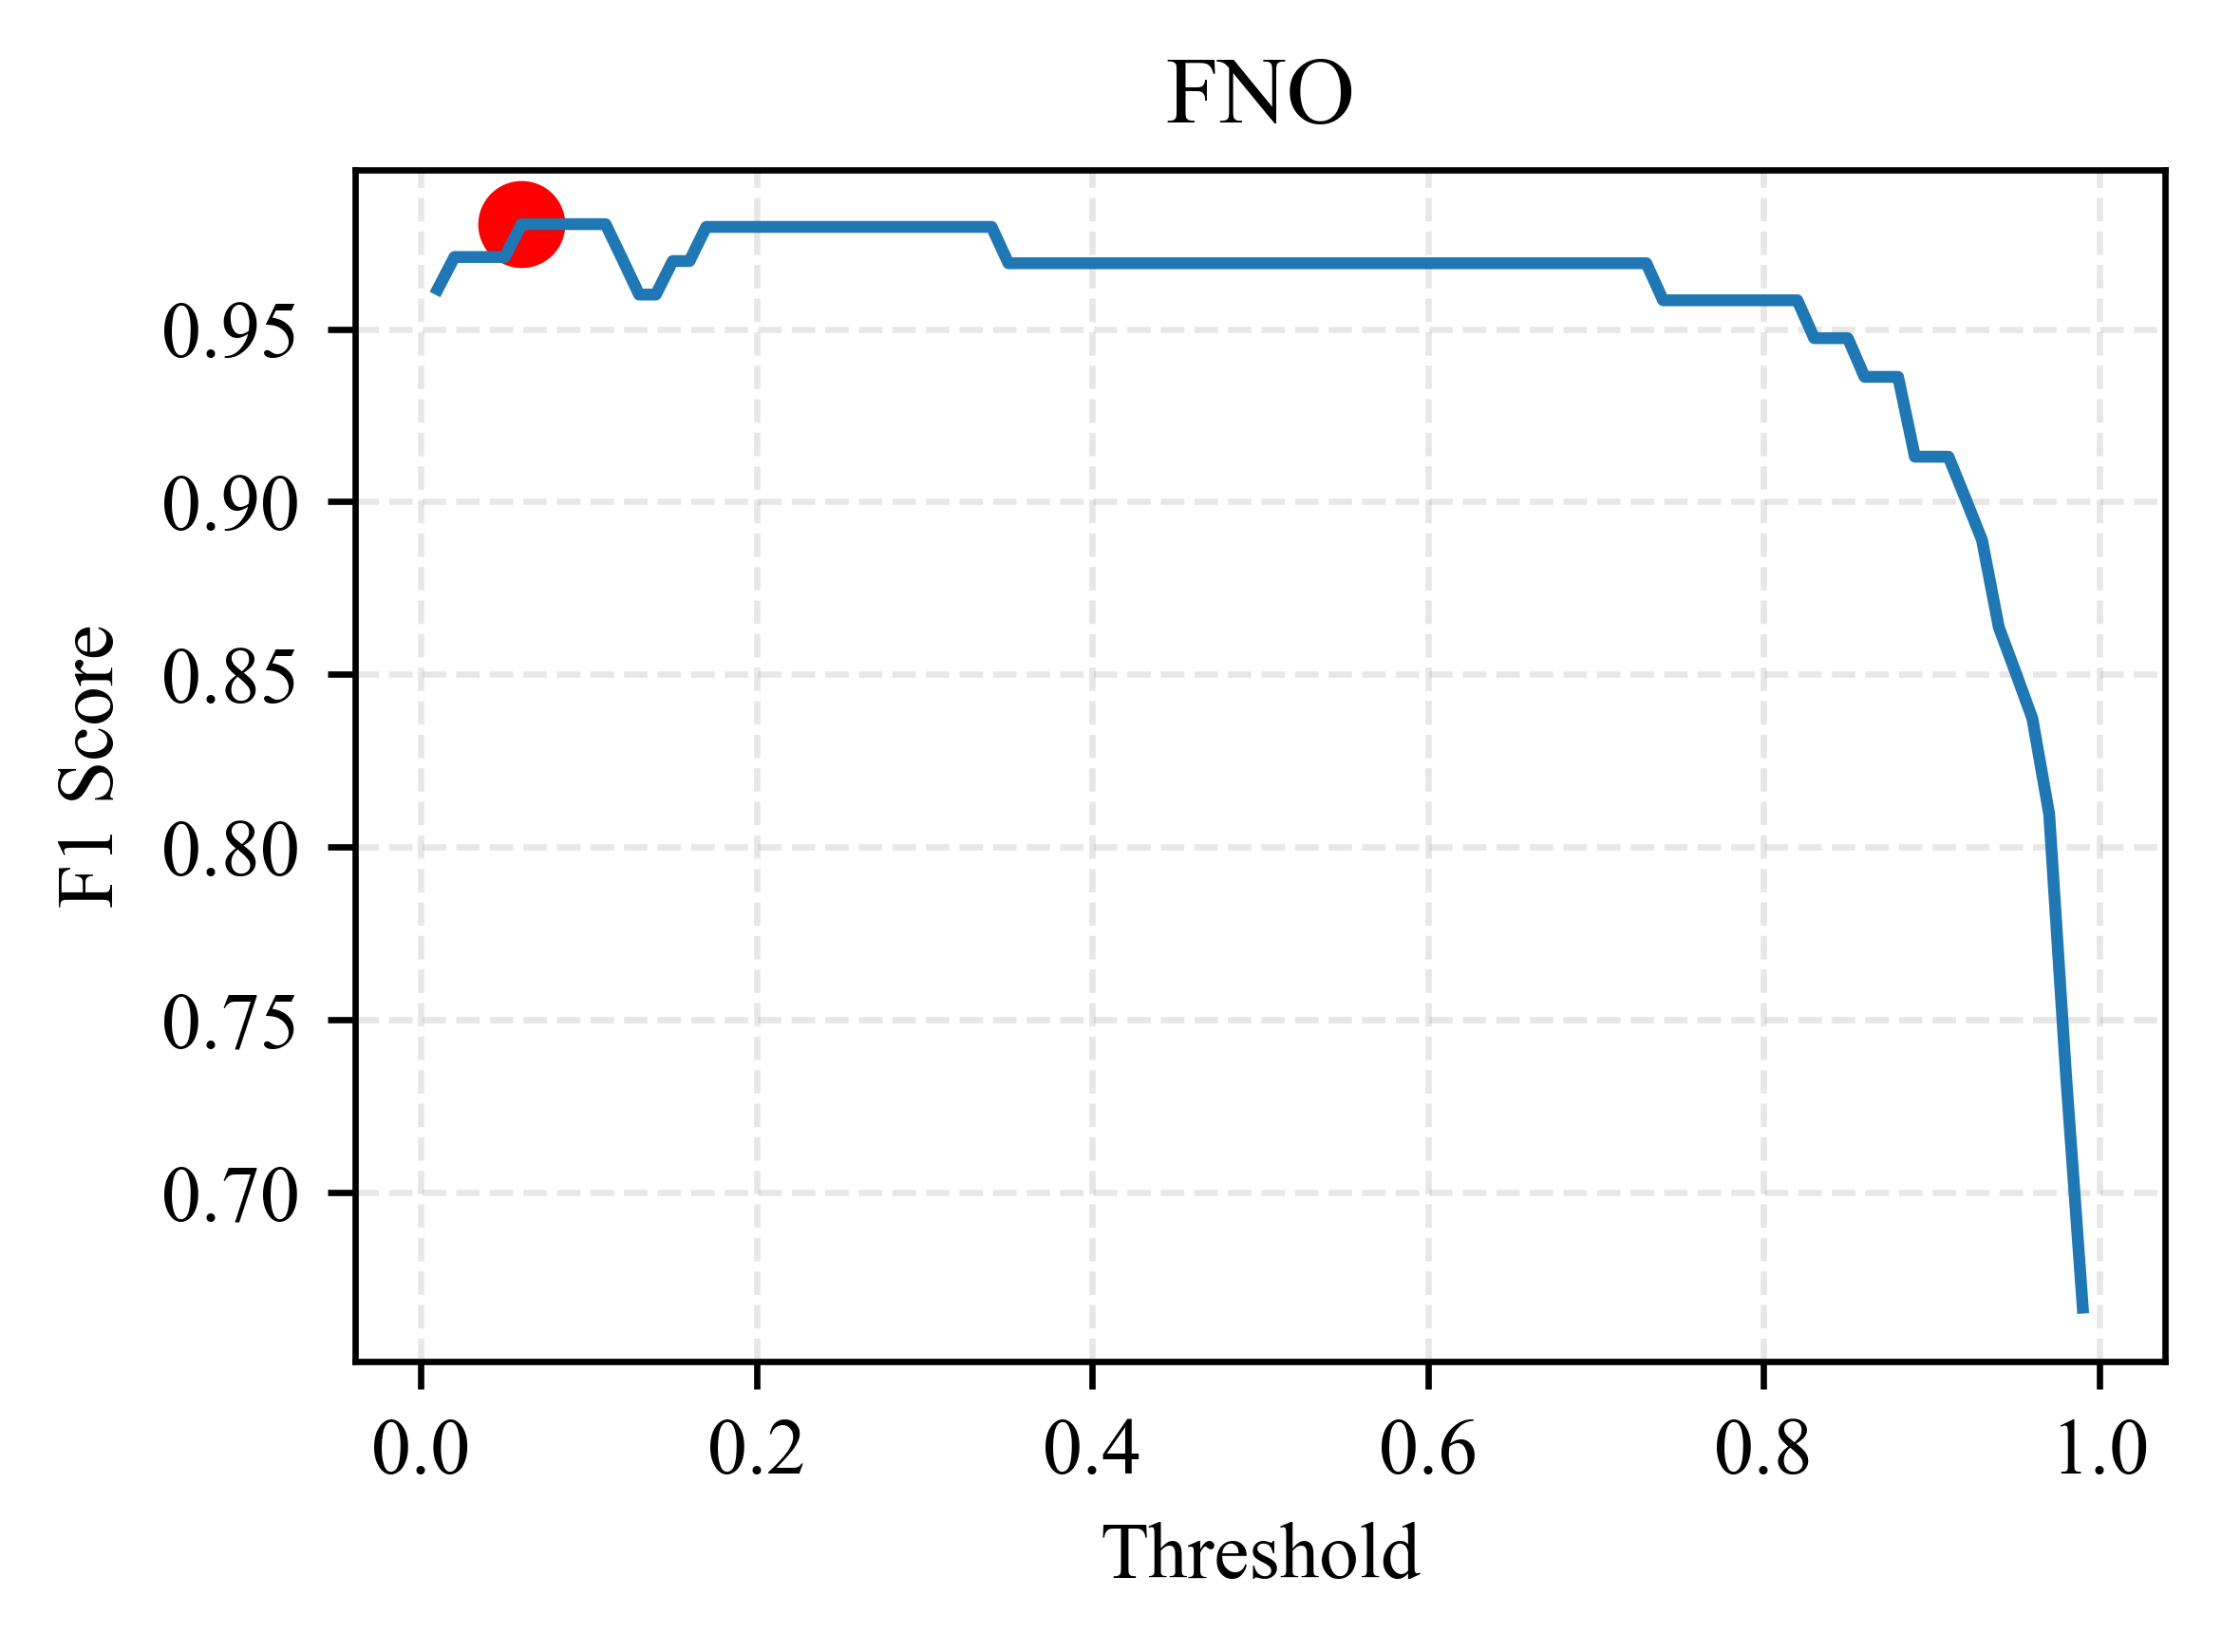

In [16]:
thresholds = np.arange(1, 100) / 100.0
f1_all = []

for th in thresholds: 

    # Convert probabilities to binary predictions (e.g., threshold at 0.5)
    all_predictions = (np.array(all_outputs) > th) 

    f1_all.append( f1_score( y_test, all_predictions, zero_division=0) )

best_th = thresholds[ np.argmax( f1_all ) ]
best_f1 = f1_all[ np.argmax( f1_all ) ]

print(f"Best F1 Score: {best_f1:.3f}, best threshold: {best_th:.2f}")

fig = plt.figure(figsize=(4, 3), dpi=600)

plt.plot( thresholds, f1_all,'-' )
plt.scatter( best_th, best_f1, s=100, c='r' )

plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('FNO')

plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

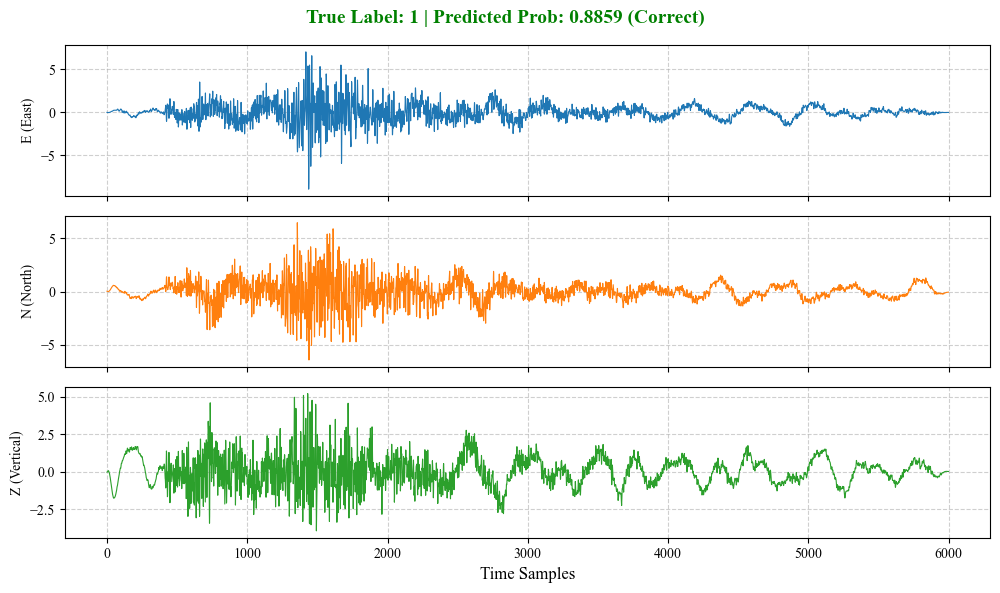

In [17]:
# 1. Fetch a single batch from the test loader
dataiter = iter(test_loader)
inputs, targets = next(dataiter)

# 2. Pick a random sample from the batch
idx = random.randint(0, inputs.size(0) - 1)
sample_trace = inputs[idx].cpu().numpy()  # Shape: (sequence_length, 3)
true_label = targets[idx].item()

# 3. Get the model's prediction for this specific sample
best_model.eval()
with torch.no_grad():
    input_tensor = inputs[idx].unsqueeze(0).to(device) # Add batch dimension
    pred_prob = best_model(input_tensor).item()
    predicted_class = 1 if pred_prob > best_th else 0 # Assuming 'best_th' is your threshold

# 4. Plotting the 3-component seismogram
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
channels = ['E (East)', 'N (North)', 'Z (Vertical)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i in range(3):
    # Plotting each channel (assuming shape is seq_len, 3)
    axes[i].plot(sample_trace[:, i], color=colors[i], linewidth=0.8)
    axes[i].set_ylabel(channels[i], fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Time Samples', fontsize=12)

# Dynamic title based on prediction accuracy
status = "Correct" if predicted_class == true_label else "Incorrect"
title_color = "green" if status == "Correct" else "red"

fig.suptitle(
    f"True Label: {int(true_label)} | Predicted Prob: {pred_prob:.4f} ({status})", 
    fontsize=14, color=title_color, fontweight='bold'
)

plt.tight_layout()
plt.show()

In [18]:
### Confusion Matrix ###

# Convert probabilities to binary predictions
all_predictions = ((np.array(all_outputs) > best_th)) 
all_targets = y_test

# Calculate confusion matrix
cm = confusion_matrix(all_targets, all_predictions)

# Extract true positives, false positives, false negatives, and true negatives
tn, fp, fn, tp = cm.ravel()

print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Negatives: {tn}")

# Calculate metrics
accuracy = accuracy_score(all_targets, all_predictions)
precision = precision_score(all_targets, all_predictions, zero_division=0)
recall = recall_score(all_targets, all_predictions, zero_division=0)
f1 = f1_score(all_targets, all_predictions, zero_division=0)

# Print results
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

True Positives: 50
False Positives: 2
False Negatives: 0
True Negatives: 48
Accuracy: 0.980
Precision: 0.962
Recall: 1.000
F1 Score: 0.980
